In [86]:
%load_ext autoreload
%autoreload 2

import torch

from retarget.model import TransformerAutoEncoder
from retarget.tokenizer import Tokenizer
from retarget.utils.BVH import load

model = TransformerAutoEncoder.from_pretrained('local/best_model')
tokenizer = Tokenizer()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cache_path ./models/local/best_model.pt
Using cached model


In [94]:
animation, _, _ = load('./data/Combined/test/bandai-namco/dataset-2_wave-right-hand_normal_030.bvh')
data = animation.as_graph()
batch, mask = tokenizer.encode(data)

len(animation)

220

In [95]:
import matplotlib.pyplot as plt
from retarget.utils.visualize import plot_pose

with torch.inference_mode():
    output, logvar = model.encoder(batch.x, batch.pos, batch.edge_index, mask=mask)
    y_pred = model.decoder(output, batch.pos, batch.edge_index, mask=mask)

fk_pose, edge_indexs = tokenizer.decode(batch, y_pred)

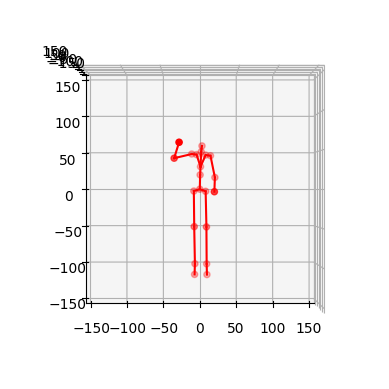

In [99]:
ax = plt.axes(projection='3d')

plot_pose(fk_pose[28].detach().numpy(), edge_indexs[28], c='r', ax=ax)

ax.set_xlim(-150, 150)
ax.set_ylim(-150, 150)
ax.set_zlim(-150, 150)
plt.show()